# A4: Support Data Insight Analysis

## Initial Imports

In [1]:
# Warning control
import warnings, sys
warnings.filterwarnings('ignore')

# Increase recursion limit
sys.setrecursionlimit(sys.getrecursionlimit() + 2000)
print(sys.getrecursionlimit())

# Load environment variables
from utils import load_env
load_env()

import yaml
from crewai import Agent, Task, Crew

5000


## Loading Tasks and Agents YAML files

In [2]:
# Define file paths for YAML configurations
files = {
    'agents': 'config/A4_agents.yaml',
    'tasks': 'config/A4_tasks.yaml'
}

# Load configurations from YAML files
configs = {}
for config_type, file_path in files.items():
    with open(file_path, 'r') as file:
        configs[config_type] = yaml.safe_load(file)

# Assign loaded configurations to specific variables
agents_config = configs['agents']
tasks_config = configs['tasks']

## Using FileReadTool

In [3]:
from crewai_tools import FileReadTool
csv_tool = FileReadTool(file_path='../../data/structured/support_tickets_data.csv')

## Creating Agents, Tasks and Crew

In [4]:
# Creating Agents
suggestion_generation_agent = Agent(
  config=agents_config['suggestion_generation_agent'],
  tools=[csv_tool]
)

reporting_agent = Agent(
  config=agents_config['reporting_agent'],
  tools=[csv_tool]
)

chart_generation_agent = Agent(
  config=agents_config['chart_generation_agent'],
  allow_code_execution=False
)

# Creating Tasks
suggestion_generation = Task(
  config=tasks_config['suggestion_generation'],
  agent=suggestion_generation_agent
)

table_generation = Task(
  config=tasks_config['table_generation'],
  agent=reporting_agent
)

chart_generation = Task(
  config=tasks_config['chart_generation'],
  agent=chart_generation_agent
)

final_report_assembly = Task(
  config=tasks_config['final_report_assembly'],
  agent=reporting_agent,
  context=[suggestion_generation, table_generation, chart_generation]
)


# Creating Crew
support_report_crew = Crew(
  agents=[
    suggestion_generation_agent,
    reporting_agent,
    chart_generation_agent
  ],
  tasks=[
    suggestion_generation,
    table_generation,
    chart_generation,
    final_report_assembly
  ],
  verbose=True
)


## Testing our Crew

In [5]:
from crewai import LLM

eval_llm = LLM(model='gpt-4o-mini')
support_report_crew.test(n_iterations=1, eval_llm=eval_llm)

╭──────────────────────────────────────────── Crew Execution Started ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 041b9be3-8997-46e3-85d4-a894d91218fb                                                                       │
│  Tool Args:                                                                                                     │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Invalid type OpenAICompletion for attribute 'model_name' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types


╭──────────────────────────────────────────────── Test Execution ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  🧪 Starting Crew Test                                                                                          │
│                                                                                                                 │
│  Crew: crew                                                                                                     │
│  ID: 18ecf90a-39a2-4ecf-8075-d34907083623                                                                       │
│  Iterations: 1                                                                                                  │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Output()

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Suggestion Engine                                                                                       │
│                                                                                                                 │
│  Task: Generate actionable suggestions for resolving each classified support ticket. The suggestions should be  │
│  based on: - Issue Type: Tailor suggestions to the specific type of issue reported. - Historical Data: Use      │
│  historical data such as resolution_time_minutes and                                                            │
│    satisfaction_rating to inform the suggestions.                                                               │
│  - Customer Feedback: Incorporate insights from customer_comments to                                            │
│    customize the suggestions further.                                                                           │
│                                                                                                                 │
│  The goal is to provide clear, actionable steps that the support team can take to resolve each issue            │
│  efficiently and effectively.                                                                                   │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭──────────────────────────────────────────────── Task Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: 7cdbfb7f-3f48-42d0-bf79-8210f6c4af38                                                                     │
│  Agent: Task Execution Evaluator                                                                                │
│  Tool Args:                                                                                                     │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

                             Tasks Scores                              
                        (1-10 Higher is better)                        
┏━━━━━━━━━━━━━━━━━━━━┯━━━━━━━┯━━━━━━━━━━━━┯━━━━━━━━━━━━━━━━━━━━━┯━━┯━━┓
┃ Tasks/Crew/Agents  │ Run 1 │ Avg. Total │ Agents              │  │  ┃
┠────────────────────┼───────┼────────────┼─────────────────────┼──┼──┨
┃ Task 1             │  9.0  │    9.0     │ - Suggestion Engine │  │  ┃
┃                    │       │            │                     │  │  ┃
┃                    │       │            │                     │  │  ┃
┃ Task 2             │  8.0  │    8.0     │ - Report Generator  │  │  ┃
┃                    │       │            │                     │  │  ┃
┃                    │       │            │                     │  │  ┃
┃ Task 3             │  9.0  │    9.0     │ - Chart Specialist  │  │  ┃
┃                    │       │            │                     │  │  ┃
┃                    │       │            │                     │  │  ┃
┃ Task 4             │  9.0  │    9.0     │ - Report Generator  │  │  ┃
┃                    │       │            │                     │  │  ┃
┃ Crew               │ 8.75  │    8.8     │                     │  │  ┃
┃ Execution Time (s) │  275  │    275     │                     │  │  ┃
┗━━━━━━━━━━━━━━━━━━━━┷━━━━━━━┷━━━━━━━━━━━━┷━━━━━━━━━━━━━━━━━━━━━┷━━┷━━┛

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 041b9be3-8997-46e3-85d4-a894d91218fb                                                                       │
│  Tool Args:                                                                                                     │
│  Final Output: ---                                                                                              │
│                                                                                                                 │
│  Final Report: Support System Performance and Improvement Insights                                              │
│                                                                                                                 │
│  ---                                                                                                            │
│                                                                                                                 │
│  1. Executive Summary                                                                                           │
│                                                                                                                 │
│  This report provides a comprehensive overview of the support system's recent performance, highlighting key     │
│  issue categories, agent effectiveness, customer satisfaction trends, and tailored actionable recommendations   │
│  to enhance service quality. Visual charts complement the tabular data for quick stakeholder comprehension.     │
│                                                                                                                 │
│  ---                                                                                                            │
│                                                                                                                 │
│  2. Issue Classification Results                                                                                │
│                                                                                                                 │
│  The support tickets are categorized into seven primary issue types: API Issue, Login Issue, Report             │
│  Generation, Data Import, Feature Request, Billing Issue, and UI Bug. The distribution and priorities of these  │
│  issues are summarized below:                                                                                   │
│                                                                                                                 │
│  | Issue Type       | Ticket Count | High Priority | Medium Priority | Low Priority | Critical Priority | Avg   │
│  Resolution Time (min) | Avg Satisfaction Rating |                                                              │
│  |------------------|--------------|---------------|-----------------|--------------|-------------------|-----  │
│  ----------------------|------------------------|                                                               │
│  | API Issue        | 7            | 3             | 1               | 0            | 3                 | 535   │
│  | 3.86                   |                                                                                     │
│  | Login Issue      | 8            | 2             | 1               | 3            | 2                 | 757   │
│  | 3.38                   |                                                                                     │
│  | Report Generation| 4            | 2             | 1

╭──────────────────────────────────────────────── Test Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Test Execution Completed                                                                                       │
│  Crew: crew                                                                                                     │
│                                                                                                                 │
│  Status: Completed                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Tracing Status ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing is disabled.                                                                                     │
│                                                                                                                 │
│  To enable tracing, do any one of these:                                                                        │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Training your crew and agents

In [6]:
import shutil
from pathlib import Path

support_report_crew.train(n_iterations=1, filename='../../data/crewai/training.pkl')

# Move the auto-generated training_data.pkl to data/generated
training_data_file = Path('training_data.pkl')
if training_data_file.exists():
    target_dir = Path('../../data/generated')
    target_dir.mkdir(parents=True, exist_ok=True)
    shutil.move(str(training_data_file), str(target_dir / 'training_data.pkl'))
    print(f"Moved training_data.pkl to {target_dir / 'training_data.pkl'}")

╭─────────────────────────────────────────────── Training Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  📋 Crew Training Started                                                                                       │
│  Crew: crew                                                                                                     │
│  Time: 2026-01-09 12:09:07.845020+00:00                                                                         │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────── Crew Execution Started ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: e9d69419-5a2c-442d-9fad-43ee5f12742a                                                                       │
│  Tool Args:                                                                                                     │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Suggestion Engine                                                                                       │
│                                                                                                                 │
│  Task: Generate actionable suggestions for resolving each classified support ticket. The suggestions should be  │
│  based on: - Issue Type: Tailor suggestions to the specific type of issue reported. - Historical Data: Use      │
│  historical data such as resolution_time_minutes and                                                            │
│    satisfaction_rating to inform the suggestions.                                                               │
│  - Customer Feedback: Incorporate insights from customer_comments to                                            │
│    customize the suggestions further.                                                                           │
│                                                                                                                 │
│  The goal is to provide clear, actionable steps that the support team can take to resolve each issue            │
│  efficiently and effectively.                                                                                   │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Output()

╭──────────────────────────────────────────── 🔧 Agent Tool Execution ────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Suggestion Engine                                                                                       │
│                                                                                                                 │
│  Thought: Action: Read a file's content                                                                         │
│                                                                                                                 │
│  Using Tool: Read a file's content                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: e9d69419-5a2c-442d-9fad-43ee5f12742a                                                                       │
│  Tool Args:                                                                                                     │
│  Final Output: Comprehensive Support System Performance Report                                                  │
│                                                                                                                 │
│  ---                                                                                                            │
│                                                                                                                 │
│  ### 1. Issue Classification Results                                                                            │
│                                                                                                                 │
│  Table: Summary of Issue Types, Frequency, Priorities, Resolution Times, and Satisfaction Ratings               │
│                                                                                                                 │
│  | Issue Type        | Frequency | Priority Distribution (Count)             | Average Resolution Time          │
│  (Minutes) | Average Satisfaction Rating |                                                                      │
│  |-------------------|-----------|------------------------------------------|---------------------------------  │
│  -|-----------------------------|                                                                               │
│  | API Issue         | 8         | Critical: 2, High: 3, Medium: 1, Low: 2  | 461                               │
│  | 4.0                         |                                                                                │
│  | Login Issue       | 9         | Critical: 2, High: 2, Medium: 1, Low: 4  | 612                               │
│  | 3.9                         |                                                                                │
│  | Report Generation | 6         | High: 2, Medium: 2, Low: 2                | 726                              │
│  | 2.0                         |                                                                                │
│  | Data Import       | 13        | High: 5, Medium: 5, Low: 3                | 704                              │
│  | 2.1                         |                                                                                │
│  | Feature Request   | 7         | Critical: 1, High: 3, Medium: 2, Low: 1  | 505                               │
│  | 2.0                         |                                                                                │
│  | Billing Issue     | 11        | Critical: 3, High: 4, Medium: 3, Low: 1  | 685                               │
│  | 2.5                         |                                                                                │
│  | UI Bug            | 7         | Critical: 2, High: 2, Medium: 2, Low: 1  | 634                               │
│  | 3.6                         |                                                                                │
│                                                                                                                 │
│  ![Issue Distribution](./issue_distribution.png)                                                                │
│  ![Priority Levels](./priority_levels.png)            

╭──────────────────────────────────────────────── Tracing Status ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing is disabled.                                                                                     │
│                                                                                                                 │
│  To enable tracing, do any one of these:                                                                        │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Output()

Moved training_data.pkl to ../../data/generated/training_data.pkl


╭────────────────────────────────────────────── Training Completed ───────────────────────────────────────────────╮
│                                                                                                                 │
│  ✅ Crew Training Completed                                                                                     │
│  Crew: crew                                                                                                     │
│  Time: 2026-01-09 12:17:40.064241+00:00                                                                         │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Comparing new test results

In [7]:
support_report_crew.test(n_iterations=1, eval_llm=eval_llm)

╭──────────────────────────────────────────── Crew Execution Started ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 017f4b62-bf5c-426e-9577-ef9bbdb7f094                                                                       │
│  Tool Args:                                                                                                     │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

WARNING:opentelemetry.attributes:Invalid type OpenAICompletion for attribute 'model_name' value. Expected one of 
['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types

╭──────────────────────────────────────────────── Test Execution ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  🧪 Starting Crew Test                                                                                          │
│                                                                                                                 │
│  Crew: crew                                                                                                     │
│  ID: 18ecf90a-39a2-4ecf-8075-d34907083623                                                                       │
│  Iterations: 1                                                                                                  │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Suggestion Engine                                                                                       │
│                                                                                                                 │
│  Task: Generate actionable suggestions for resolving each classified support ticket. The suggestions should be  │
│  based on: - Issue Type: Tailor suggestions to the specific type of issue reported. - Historical Data: Use      │
│  historical data such as resolution_time_minutes and                                                            │
│    satisfaction_rating to inform the suggestions.                                                               │
│  - Customer Feedback: Incorporate insights from customer_comments to                                            │
│    customize the suggestions further.                                                                           │
│                                                                                                                 │
│  The goal is to provide clear, actionable steps that the support team can take to resolve each issue            │
│  efficiently and effectively.                                                                                   │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Output()

...

╭──────────────────────────────────────────────── Task Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: 849e9444-8ffa-4606-8cb4-a4bf323c75db                                                                     │
│  Agent: Task Execution Evaluator                                                                                │
│  Tool Args:                                                                                                     │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

                             Tasks Scores                              
                        (1-10 Higher is better)                        
┏━━━━━━━━━━━━━━━━━━━━┯━━━━━━━┯━━━━━━━━━━━━┯━━━━━━━━━━━━━━━━━━━━━┯━━┯━━┓
┃ Tasks/Crew/Agents  │ Run 1 │ Avg. Total │ Agents              │  │  ┃
┠────────────────────┼───────┼────────────┼─────────────────────┼──┼──┨
┃ Task 1             │  9.0  │    9.0     │ - Suggestion Engine │  │  ┃
┃                    │       │            │                     │  │  ┃
┃                    │       │            │                     │  │  ┃
┃ Task 2             │  8.0  │    8.0     │ - Report Generator  │  │  ┃
┃                    │       │            │                     │  │  ┃
┃                    │       │            │                     │  │  ┃
┃ Task 3             │  9.0  │    9.0     │ - Chart Specialist  │  │  ┃
┃                    │       │            │                     │  │  ┃
┃                    │       │            │                     │  │  ┃
┃ Task 4             │  9.0  │    9.0     │ - Report Generator  │  │  ┃
┃                    │       │            │                     │  │  ┃
┃ Crew               │ 8.75  │    8.8     │                     │  │  ┃
┃ Execution Time (s) │  124  │    124     │                     │  │  ┃
┗━━━━━━━━━━━━━━━━━━━━┷━━━━━━━┷━━━━━━━━━━━━┷━━━━━━━━━━━━━━━━━━━━━┷━━┷━━┛

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 017f4b62-bf5c-426e-9577-ef9bbdb7f094                                                                       │
│  Tool Args:                                                                                                     │
│  Final Output: Comprehensive Support Tickets Performance Report                                                 │
│                                                                                                                 │
│  ---                                                                                                            │
│                                                                                                                 │
│  Section 1: Issue Classification Results                                                                        │
│                                                                                                                 │
│  Overview:                                                                                                      │
│  This section presents a detailed classification of issues reported in support tickets, highlighting the total  │
│  ticket volume per issue type and their priority levels. This helps identify the most common challenges and     │
│  focus areas.                                                                                                   │
│                                                                                                                 │
│  Table 1.1: Issue Classification Summary                                                                        │
│                                                                                                                 │
│  | Issue Type        | Total Tickets | Critical | High | Medium | Low |                                         │
│  |-------------------|---------------|----------|------|--------|-----|                                         │
│  | API Issue         | 7             | 2        | 4    | 0      | 1   |                                         │
│  | Login Issue       | 7             | 2        | 2    | 1      | 2   |                                         │
│  | Report Generation | 5             | 1        | 2    | 2      | 0   |                                         │
│  | Data Import       | 13            | 1        | 6    | 4      | 2   |                                         │
│  | Feature Request   | 6             | 2        | 2    | 2      | 0   |                                         │
│  | Billing Issue     | 12            | 3        | 5    | 3      | 1   |                                         │
│  | UI Bug            | 7             | 2        | 2    | 2      | 1   |                                         │
│                                                                                                                 │
│  Visuals:                                                                                                       │
│                                                                                                                 │
│  - Issue Distribution Chart:                                                                                    │
│    ![issue_distribution.png](./issue_distribution.png)                                                          │
│    This pie chart shows the proportion of support tickets by issue type, revealing that Data Import and         │
│  Billing Issues compose the largest shares of the work

╭──────────────────────────────────────────────── Test Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Test Execution Completed                                                                                       │
│  Crew: crew                                                                                                     │
│                                                                                                                 │
│  Status: Completed                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Tracing Status ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing is disabled.                                                                                     │
│                                                                                                                 │
│  To enable tracing, do any one of these:                                                                        │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

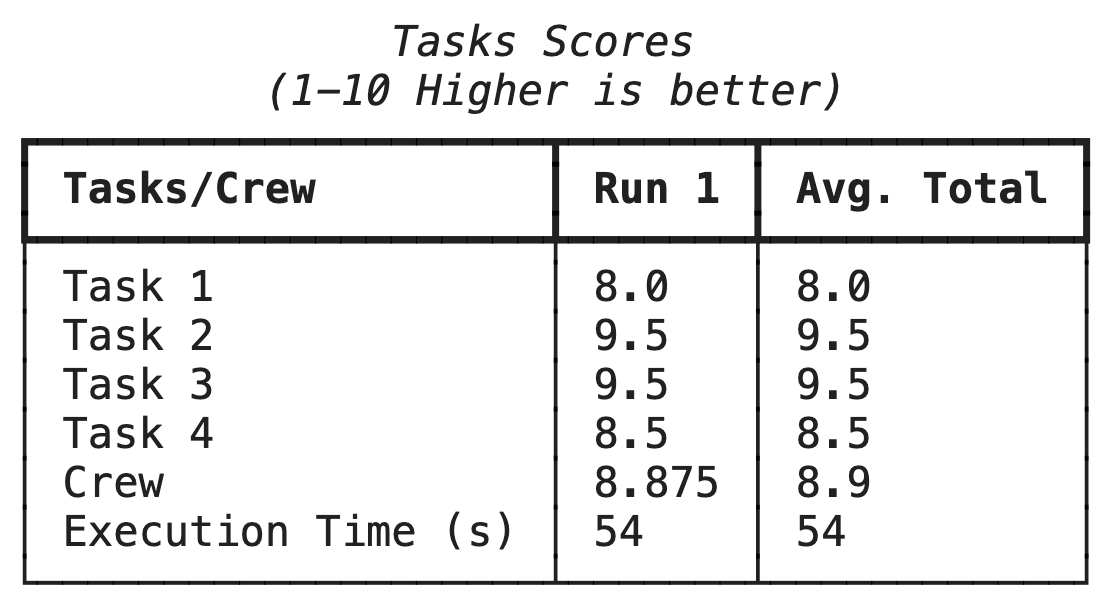

In [8]:
# Display the Trello screenshot
from IPython.display import Image, display

# Load and display the image
test_image = Image(filename='../../data/crewai/test_before_training.png', width=368)
display(test_image)

## Kicking off Crew

In [9]:
result = support_report_crew.kickoff()

╭──────────────────────────────────────────── Crew Execution Started ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 18ecf90a-39a2-4ecf-8075-d34907083623                                                                       │
│  Tool Args:                                                                                                     │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Suggestion Engine                                                                                       │
│                                                                                                                 │
│  Task: Generate actionable suggestions for resolving each classified support ticket. The suggestions should be  │
│  based on: - Issue Type: Tailor suggestions to the specific type of issue reported. - Historical Data: Use      │
│  historical data such as resolution_time_minutes and                                                            │
│    satisfaction_rating to inform the suggestions.                                                               │
│  - Customer Feedback: Incorporate insights from customer_comments to                                            │
│    customize the suggestions further.                                                                           │
│                                                                                                                 │
│  The goal is to provide clear, actionable steps that the support team can take to resolve each issue            │
│  efficiently and effectively.                                                                                   │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Output()

Output()

╭──────────────────────────────────────────── 🔧 Agent Tool Execution ────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Suggestion Engine                                                                                       │
│                                                                                                                 │
│  Thought: Thought: To generate actionable suggestions for resolving each classified support ticket, I first     │
│  need to examine the available support ticket data, including the issue type, resolution time, satisfaction     │
│  rating, and customer comments. This will allow me to understand common issues, resolution approaches, and      │
│  feedback from customers. I will start by reading the entire support tickets data file to gather all necessary  │
│  information for comprehensive suggestions.                                                                     │
│                                                                                                                 │
│  Using Tool: Read a file's content                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Report Generator                                                                                        │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  Support System Performance and Issue Insights Report                                                           │
│  ---------------------------------------------------                                                            │
│                                                                                                                 │
│  This report summarizes key findings from the support ticket data, highlighting issue classification results,   │
│  agent performance, customer satisfaction trends, and actionable recommendations to improve support outcomes.   │
│                                                                                                                 │
│  ---                                                                                                            │
│                                                                                                                 │
│  1. Issue Classification Results                                                                                │
│                                                                                                                 │
│  This section provides an overview of the types of issues reported, their frequency, and priority               │
│  distributions.                                                                                                 │
│                                                                                                                 │
│  Table 1: Issue Classification Results                                                                          │
│                                                                                                                 │
│  | Issue Type        | Frequency | Priority Distribution (Count)           |                                    │
│  |-------------------|-----------|----------------------------------------|                                     │
│  | API Issue         | 6         | Critical: 2, High: 3, Medium: 0, Low: 1|                                     │
│  | Login Issue       | 7         | Critical: 3, High: 1, Medium: 0, Low: 3|                                     │
│  | Report Generation | 5         | Critical: 0, High: 2, Medium: 2, Low: 1|                                     │
│  | Data Import       | 12        | Critical: 0, High: 5, Medium: 5, Low: 2|                                     │
│  | Feature Request   | 7         | Critical: 1, High: 3, Medium: 2, Low: 1|                                     │
│  | Billing Issue     | 13        | Critical: 3, High: 5, Medium: 4, Low: 1|                                     │
│  | UI Bug            | 7         | Critical: 1, High: 3, Medium: 2, Low: 1|                                     │
│                                                                                                                 │
│  Charts:                                                                                                        │
│                                                                                                                 │
│  - Issue Distribution Pie Chart                                                                                 │
│    This chart visualizes the proportional frequency of different issue types, showing Data Import and Billing   │
│  Issues as the most frequent.                          

Output()

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 18ecf90a-39a2-4ecf-8075-d34907083623                                                                       │
│  Tool Args:                                                                                                     │
│  Final Output: Support System Performance and Issue Insights Report                                             │
│  ---------------------------------------------------                                                            │
│                                                                                                                 │
│  This report summarizes key findings from the support ticket data, highlighting issue classification results,   │
│  agent performance, customer satisfaction trends, and actionable recommendations to improve support outcomes.   │
│                                                                                                                 │
│  ---                                                                                                            │
│                                                                                                                 │
│  1. Issue Classification Results                                                                                │
│                                                                                                                 │
│  This section provides an overview of the types of issues reported, their frequency, and priority               │
│  distributions.                                                                                                 │
│                                                                                                                 │
│  Table 1: Issue Classification Results                                                                          │
│                                                                                                                 │
│  | Issue Type        | Frequency | Priority Distribution (Count)           |                                    │
│  |-------------------|-----------|----------------------------------------|                                     │
│  | API Issue         | 6         | Critical: 2, High: 3, Medium: 0, Low: 1|                                     │
│  | Login Issue       | 7         | Critical: 3, High: 1, Medium: 0, Low: 3|                                     │
│  | Report Generation | 5         | Critical: 0, High: 2, Medium: 2, Low: 1|                                     │
│  | Data Import       | 12        | Critical: 0, High: 5, Medium: 5, Low: 2|                                     │
│  | Feature Request   | 7         | Critical: 1, High: 3, Medium: 2, Low: 1|                                     │
│  | Billing Issue     | 13        | Critical: 3, High: 5, Medium: 4, Low: 1|                                     │
│  | UI Bug            | 7         | Critical: 1, High: 3, Medium: 2, Low: 1|                                     │
│                                                                                                                 │
│  Charts:                                                                                                        │
│                                                                                                                 │
│  - Issue Distribution Pie Chart                                                                                 │
│    This chart visualizes the proportional frequency of

╭──────────────────────────────────────────────── Task Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: f5d95fdf-fac1-486b-ae3b-5eddc9b36291                                                                     │
│  Agent: Report Generator                                                                                        │
│                                                                                                                 │
│  Tool Args:                                                                                                     │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Tracing Status ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing is disabled.                                                                                     │
│                                                                                                                 │
│  To enable tracing, do any one of these:                                                                        │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Result

In [10]:
from IPython.display import display, Markdown
display(Markdown(result.raw))

Support System Performance and Issue Insights Report
---------------------------------------------------

This report summarizes key findings from the support ticket data, highlighting issue classification results, agent performance, customer satisfaction trends, and actionable recommendations to improve support outcomes.

---

1. Issue Classification Results

This section provides an overview of the types of issues reported, their frequency, and priority distributions.

Table 1: Issue Classification Results

| Issue Type        | Frequency | Priority Distribution (Count)           |
|-------------------|-----------|----------------------------------------|
| API Issue         | 6         | Critical: 2, High: 3, Medium: 0, Low: 1|
| Login Issue       | 7         | Critical: 3, High: 1, Medium: 0, Low: 3|
| Report Generation | 5         | Critical: 0, High: 2, Medium: 2, Low: 1|
| Data Import       | 12        | Critical: 0, High: 5, Medium: 5, Low: 2|
| Feature Request   | 7         | Critical: 1, High: 3, Medium: 2, Low: 1|
| Billing Issue     | 13        | Critical: 3, High: 5, Medium: 4, Low: 1|
| UI Bug            | 7         | Critical: 1, High: 3, Medium: 2, Low: 1|

Charts:

- Issue Distribution Pie Chart  
  This chart visualizes the proportional frequency of different issue types, showing Data Import and Billing Issues as the most frequent.  
  ![Issue Distribution](./issue_distribution.png)

- Ticket Priority Levels by Issue Type (Stacked Bar Chart)  
  Provides a side-by-side comparison of priority levels across issue types, highlighting critical concentrations in API, Login, Billing, and UI Bug tickets.  
  ![Priority Levels](./priority_levels.png)

---

2. Agent Performance

Agent metrics including tickets handled, average resolution times, response times, and customer satisfaction ratings provide insights into support team effectiveness.

Table 2: Agent Performance

| Agent ID | Tickets Handled | Avg Resolution Time (minutes) | Avg Response Time (minutes) | Avg Satisfaction Rating |
|----------|-----------------|-------------------------------|-----------------------------|-------------------------|
| A001     | 7               | 657                           | 121                         | 2.43                    |
| A002     | 8               | 837                           | 142                         | 3.25                    |
| A003     | 11              | 759                           | 112                         | 2.55                    |
| A004     | 18              | 706                           | 133                         | 3.00                    |
| A005     | 7               | 860                           | 109                         | 2.86                    |

Charts:

- Average Resolution Time per Agent (Bar Chart)  
  Depicts the resolution speed per agent, revealing that Agent A005 has the highest average resolution time.  
  ![Resolution Times](./resolution_times.png)

- Agent Performance Comparison Chart (Combined Bar and Line)  
  Compares resolution time (bar) against average satisfaction rating (line), illustrating trade-offs between resolution speed and customer satisfaction ratings per agent.  
  ![Agent Performance](./agent_performance.png)

---

3. Customer Satisfaction

A monthly overview of average customer satisfaction ratings and tickets resolved shows temporal trends and support system effectiveness over time.

Table 3: Customer Satisfaction Over Time (Monthly Average)

| Month-Year | Avg Satisfaction Rating | Tickets Resolved |
|------------|-------------------------|------------------|
| Jan-2023   | 2.06                    | 9                |
| Feb-2023   | 3.00                    | 6                |
| Mar-2023   | 2.67                    | 12               |
| Apr-2023   | 3.60                    | 7                |
| May-2023   | 2.84                    | 10               |
| Jun-2023   | 3.13                    | 9                |
| Jul-2023   | 3.00                    | 1                |

Chart:

- Average Customer Satisfaction Over Time (Line Chart)  
  Tracks satisfaction improvements and dips, noting a peak in April 2023. Useful for identifying factors influencing satisfaction shifts.  
  ![Customer Satisfaction](./customer_satisfaction_trend.png)

---

4. Suggested Actions by Issue Category

Based on issue types and their priority levels, the following actionable recommendations are proposed to enhance resolution efficiency and customer experience:

- API Issue
  - Prioritize rapid response/resolution to reduce repeat frustrations.
  - Conduct root cause analysis for recurring issues.
  - Maintain proactive, transparent communication.
  - Expedite escalation of critical cases to expert agents.

- Login Issue
  - Use diagnostic tools to accelerate identification.
  - Prioritize critical and unresolved tickets.
  - Provide temporary workarounds for persistent problems.
  - Implement automated notifications to set clear expectations.

- Report Generation
  - Train agents with problem-specific checklists.
  - Escalate bugs promptly to development.
  - Assign experienced staff for complex cases.
  - Follow up to confirm resolution completeness.

- Data Import
  - Develop diagnostic tools to shorten troubleshooting.
  - Track/fix recurring import errors proactively.
  - Communicate estimated timelines clearly.
  - Prioritize high-severity/repeat issues.
  - Proactively reach out to affected customers.

- Feature Request
  - Provide frequent status updates.
  - Manage expectations on delivery timelines.
  - Assign dedicated personnel for feature requests.
  - Collect detailed inputs to guide development.
  - Suggest temporary alternatives when possible.

- Billing Issue
  - Enforce rapid response SLA adherence.
  - Equip agents with comprehensive billing knowledge.
  - Use automated acknowledgments and follow-ups.
  - Proactively confirm resolution with customers.

- UI Bug
  - Quickly escalate critical UI bugs.
  - Maintain knowledge base of common bugs.
  - Keep customers informed on fix progress.
  - Confirm post-resolution satisfaction.
  - Use empathetic communication for disruptions.

---

Report Summary and Insights:

- The majority of support tickets fall under Billing Issue (13) and Data Import (12), indicating these areas require special focus.
- Critical priority tickets are concentrated notably in API, Login, Billing, and UI Bug categories, necessitating swift escalation protocols.
- Agent A004 handles the most tickets with moderate resolution times and solid customer satisfaction, suggesting effective workload management.
- Agents with the longest resolution times (e.g., A005) should be supported with process optimization training to reduce delays.
- Customer satisfaction has fluctuated over the months but shows recent stabilization around 3.0, indicating moderately positive customer experiences.
- Suggested actions emphasize improving resolution speed, customer communication transparency, and issue root cause analyses to reduce recurrences.
- Visual data representations provided enable stakeholders to quickly grasp issue composition, agent performance tradeoffs, and satisfaction trends for strategic decision-making.

All charts and tables are formatted for easy readability and side-by-side display in presentations or stakeholder dashboards, ensuring the report is a comprehensive resource for improving support operations and customer experience.

---

End of Report.